
# Strong Conditional vs Forced-Correction Experiment

このノートブックは、**条件付き指示が本当に内部表現を分岐させるか**を、前回より強いA/B条件で調べるための実験です。

## 今回の比較条件
- **A_force_correction**  
  「この文は誤りを含む前提で、必ず修正する」
- **B_judge_then_fix**  
  「まず誤り有無を判定し、誤りがあるときだけ修正。正しければ原文を一字一句そのまま返す」

## ねらい
前回は A/B の内部表現差がほぼ出ませんでした。今回は次を強くします。

1. **A側に “必ず修正” を明示**
2. **B側に “まず判定” と “正しいなら一字一句そのまま” を明示**
3. **正文データを多めに置き、over-correction を測る**
4. **prompt/output の hidden states を層ごとに比較**
5. **正文だけ・誤文だけで分けて集計**

## 期待される差
- **A** は正文に対しても unnecessary correction を起こしやすい
- **B** は正文保持率が高くなりやすい
- prompt hidden state で  
  - **A**: `forced_edit_mode`, `high_confidence` が高い  
  - **B**: `judge_first_mode`, `uncertainty_monitoring` が高い  
  方向の差が出る可能性があります


In [1]:
# Cell 1: 必要ライブラリのインストール
!pip -q install -U transformers accelerate sentence-transformers scikit-learn pandas matplotlib scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pa

In [2]:

# Cell 2: 基本ライブラリ
import os
import re
import gc
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from scipy.stats import ttest_rel

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


device: cpu
cuda available: False


In [3]:

# Cell 3: 実験設定
MODEL_LIST = [
    {
        "name": "Qwen/Qwen2.5-0.5B",
        "label": "qwen_0.5b_base",
        "family": "Qwen2.5",
        "size": "0.5B",
        "instruction_tuned": False,
    },
    {
        "name": "Qwen/Qwen2.5-1.5B-Instruct",
        "label": "qwen_1.5b_instruct",
        "family": "Qwen2.5",
        "size": "1.5B",
        "instruction_tuned": True,
    },
]

MAX_NEW_TOKENS = 48
SAVE_DIR = "/content/grammar_confidence_strong_conditions"
os.makedirs(SAVE_DIR, exist_ok=True)

# 前回は system prompt が「誤りがない場合は原文そのまま」と先に教えていたので、
# ユーザー指示の差が潰れる可能性がありました。今回は中立化します。
SYSTEM_PROMPT = (
    "You are an English grammar assistant. "
    "Follow the user's instruction exactly. "
    "Return only the final answer unless the user explicitly requests a format."
)


In [4]:

# Cell 4: 強めた比較条件
PROMPT_CONDITIONS = [
    {
        "condition": "A_force_correction",
        "instruction": (
            "次の英文は文法的に誤っています。"
            "必ず修正文を返してください。"
            "原文をそのまま返してはいけません。"
            "説明は不要です。"
        )
    },
    {
        "condition": "B_judge_then_fix",
        "instruction": (
            "次の英文に文法的誤りがあるかをまず判断してください。"
            "誤りがある場合のみ修正文を返してください。"
            "誤りがない場合は原文を一字一句そのまま返してください。"
            "説明は不要です。"
        )
    },
]

def build_user_prompt(instruction, sentence):
    return f"{instruction}\n\n英文: {sentence}\n\n出力:"


In [5]:

# Cell 5: データセット
# 正文を多めにし、"A が余計に直しやすいか" を見やすくする
DATA = [
    # clearly incorrect
    {"id": "e01", "sentence": "She go to school every day.", "gold": "She goes to school every day.", "has_error": True},
    {"id": "e02", "sentence": "He don't like carrots.", "gold": "He doesn't like carrots.", "has_error": True},
    {"id": "e03", "sentence": "There is many books on the table.", "gold": "There are many books on the table.", "has_error": True},
    {"id": "e04", "sentence": "Yesterday I go to the library.", "gold": "Yesterday I went to the library.", "has_error": True},
    {"id": "e05", "sentence": "My brother can sings very well.", "gold": "My brother can sing very well.", "has_error": True},
    {"id": "e06", "sentence": "If I will see him, I will tell him.", "gold": "If I see him, I will tell him.", "has_error": True},
    {"id": "e07", "sentence": "Each of the students have a laptop.", "gold": "Each of the students has a laptop.", "has_error": True},
    {"id": "e08", "sentence": "She enjoys to read novels.", "gold": "She enjoys reading novels.", "has_error": True},

    # correct / likely to tempt rewriting
    {"id": "c01", "sentence": "She goes to school every day.", "gold": "She goes to school every day.", "has_error": False},
    {"id": "c02", "sentence": "He doesn't like carrots.", "gold": "He doesn't like carrots.", "has_error": False},
    {"id": "c03", "sentence": "There are many books on the table.", "gold": "There are many books on the table.", "has_error": False},
    {"id": "c04", "sentence": "Yesterday I went to the library.", "gold": "Yesterday I went to the library.", "has_error": False},
    {"id": "c05", "sentence": "My brother can sing very well.", "gold": "My brother can sing very well.", "has_error": False},
    {"id": "c06", "sentence": "If I see him, I will tell him.", "gold": "If I see him, I will tell him.", "has_error": False},
    {"id": "c07", "sentence": "Each of the students has a laptop.", "gold": "Each of the students has a laptop.", "has_error": False},
    {"id": "c08", "sentence": "She enjoys reading novels.", "gold": "She enjoys reading novels.", "has_error": False},
    {"id": "c09", "sentence": "The information is very useful.", "gold": "The information is very useful.", "has_error": False},
    {"id": "c10", "sentence": "No one knows the answer.", "gold": "No one knows the answer.", "has_error": False},
    {"id": "c11", "sentence": "Ten dollars is enough.", "gold": "Ten dollars is enough.", "has_error": False},
    {"id": "c12", "sentence": "The team is winning.", "gold": "The team is winning.", "has_error": False},
]
print("n examples:", len(DATA), "| incorrect:", sum(d["has_error"] for d in DATA), "| correct:", sum(not d["has_error"] for d in DATA))


n examples: 20 | incorrect: 8 | correct: 12


In [6]:

# Cell 6: ユーティリティ
def safe_text(x, fallback=""):
    if x is None:
        return fallback
    x = str(x)
    return x if len(x.strip()) > 0 else fallback

def normalize_sentence(s):
    s = safe_text(s)
    s = s.replace("\u2019", "'").replace("\u2018", "'").replace("\u201c", '"').replace("\u201d", '"')
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_vec(v):
    v = np.asarray(v, dtype=np.float32)
    n = np.linalg.norm(v)
    if n == 0:
        return v
    return v / n

def mean_normalize(mat):
    return normalize_vec(np.mean(mat, axis=0))

def cosine_sim(a, b):
    a = normalize_vec(a)
    b = normalize_vec(b)
    return float(np.dot(a, b))

def lexical_change_ratio(src, pred):
    src_toks = normalize_sentence(src).split()
    pred_toks = normalize_sentence(pred).split()
    if len(src_toks) == 0 and len(pred_toks) == 0:
        return 0.0
    max_len = max(len(src_toks), len(pred_toks), 1)
    diffs = sum(1 for i in range(max_len) if (src_toks[i] if i < len(src_toks) else None) != (pred_toks[i] if i < len(pred_toks) else None))
    return diffs / max_len

def detect_hedging(text):
    text = safe_text(text).lower()
    hedges = [
        "maybe", "perhaps", "possibly", "might", "may", "it seems", "i think",
        "probably", "likely", "unclear", "not sure", "if needed", "if necessary"
    ]
    return int(any(h in text for h in hedges))

def response_directness(text):
    text = normalize_sentence(text)
    if len(text) == 0:
        return 0.0
    if "\n" not in text and len(text.split()) <= 18:
        return 1.0
    return 0.5

def cohen_d_paired(x, y):
    d = np.asarray(x) - np.asarray(y)
    sd = np.std(d, ddof=1) if len(d) > 1 else np.nan
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(np.mean(d) / sd)


In [7]:

# Cell 7: モデル読み込み
@dataclass
class ModelBundle:
    tokenizer: object
    model: object
    config: dict

def load_model_bundle(model_cfg):
    tokenizer = AutoTokenizer.from_pretrained(model_cfg["name"], trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_cfg["name"],
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )
    if not torch.cuda.is_available():
        model = model.to(device)

    return ModelBundle(
        tokenizer=tokenizer,
        model=model,
        config=model_cfg,
    )

embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("embedding model loaded")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedding model loaded


In [8]:

# Cell 8: プロンプト整形・生成・hidden state 取得
def format_prompt(bundle, user_prompt, system_prompt=SYSTEM_PROMPT):
    tokenizer = bundle.tokenizer
    user_prompt = safe_text(user_prompt)
    if hasattr(tokenizer, "apply_chat_template") and bundle.config["instruction_tuned"]:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return f"{system_prompt}\n\n{user_prompt}"

def bundle_device(bundle):
    try:
        return bundle.model.device
    except Exception:
        return next(bundle.model.parameters()).device

def tokenize_to_device(bundle, text):
    inputs = bundle.tokenizer(text, return_tensors="pt", truncation=True)
    dev = bundle_device(bundle)
    return {k: v.to(dev) for k, v in inputs.items()}

def get_hidden_states_last_token(bundle, text):
    text = safe_text(text, fallback=".")
    inputs = tokenize_to_device(bundle, text)
    with torch.no_grad():
        outputs = bundle.model(**inputs, output_hidden_states=True, use_cache=False)
    seq_len = inputs["input_ids"].shape[1]
    last_pos = max(0, seq_len - 1)
    layer_vecs = []
    for hs in outputs.hidden_states:
        vec = hs[0, last_pos, :].detach().float().cpu().numpy()
        layer_vecs.append(normalize_vec(vec))
    return layer_vecs

def get_prompt_end_hidden_states(bundle, user_prompt):
    formatted_prompt = format_prompt(bundle, user_prompt)
    return get_hidden_states_last_token(bundle, formatted_prompt)

def generate_with_scores(bundle, user_prompt, max_new_tokens=MAX_NEW_TOKENS):
    formatted_prompt = format_prompt(bundle, user_prompt)
    tokenizer = bundle.tokenizer
    model = bundle.model

    inputs = tokenizer(formatted_prompt, return_tensors="pt", truncation=True)
    dev = bundle_device(bundle)
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_ids = gen_ids.sequences[0]
    gen_only_ids = full_ids[prompt_len:]
    decoded = tokenizer.decode(gen_only_ids, skip_special_tokens=True).strip()
    decoded = normalize_sentence(decoded)

    token_logprobs = []
    for step, scores in enumerate(gen_ids.scores):
        if step >= len(gen_only_ids):
            break
        log_probs = torch.log_softmax(scores[0], dim=-1)
        tok_id = gen_only_ids[step]
        token_logprobs.append(float(log_probs[tok_id].detach().cpu().item()))

    mean_logprob = float(np.mean(token_logprobs)) if token_logprobs else np.nan
    min_logprob = float(np.min(token_logprobs)) if token_logprobs else np.nan

    return {
        "formatted_prompt": formatted_prompt,
        "generated": decoded,
        "token_logprobs": token_logprobs,
        "mean_logprob": mean_logprob,
        "min_logprob": min_logprob,
        "n_generated_tokens": int(len(gen_only_ids)),
    }


In [9]:

# Cell 9: 内部表現比較用アンカー
ANCHOR_TEXTS = {
    "forced_edit_mode": [
        "The sentence is assumed to be wrong and must be edited.",
        "A correction is definitely required.",
        "Do not keep the original sentence; rewrite it.",
    ],
    "judge_first_mode": [
        "First determine whether an error exists, then decide whether to revise.",
        "Correction should happen only if a real grammatical error is present.",
        "The system must check correctness before editing.",
    ],
    "high_confidence": [
        "The answer is obvious and can be given confidently.",
        "I am certain that revision is required.",
        "This case is straightforward.",
    ],
    "uncertainty_monitoring": [
        "It is necessary to verify whether an error exists before changing anything.",
        "The need for revision is uncertain until the sentence is checked.",
        "This may or may not require correction.",
    ],
}

def build_anchor_vectors(bundle, anchor_texts):
    layer_lists = [get_hidden_states_last_token(bundle, t) for t in anchor_texts]
    n_layers = len(layer_lists[0])
    out = []
    for layer_idx in range(n_layers):
        stack = np.stack([vecs[layer_idx] for vecs in layer_lists], axis=0)
        out.append(mean_normalize(stack))
    return out

def score_against_anchor(vecs, anchor_vecs):
    return [cosine_sim(v, a) for v, a in zip(vecs, anchor_vecs)]


In [10]:

# Cell 10: 出力評価
def semantic_similarity(a, b, model):
    a_vec = normalize_vec(model.encode(safe_text(a), convert_to_numpy=True))
    b_vec = normalize_vec(model.encode(safe_text(b), convert_to_numpy=True))
    return cosine_sim(a_vec, b_vec)

def evaluate_output(src, gold, pred, has_error, embed_model):
    src_n = normalize_sentence(src)
    gold_n = normalize_sentence(gold)
    pred_n = normalize_sentence(pred)

    exact_match_gold = int(pred_n == gold_n)
    unchanged_from_input = int(pred_n == src_n)
    changed = int(pred_n != src_n)

    corrected_when_needed = int(has_error and pred_n == gold_n)
    preserved_when_correct = int((not has_error) and pred_n == src_n)
    overcorrected_when_correct = int((not has_error) and pred_n != src_n)
    failed_to_change_when_needed = int(has_error and pred_n == src_n)

    semantic_to_gold = semantic_similarity(pred_n, gold_n, embed_model)
    semantic_to_input = semantic_similarity(pred_n, src_n, embed_model)

    return {
        "pred_norm": pred_n,
        "exact_match_gold": exact_match_gold,
        "unchanged_from_input": unchanged_from_input,
        "changed": changed,
        "corrected_when_needed": corrected_when_needed,
        "preserved_when_correct": preserved_when_correct,
        "overcorrected_when_correct": overcorrected_when_correct,
        "failed_to_change_when_needed": failed_to_change_when_needed,
        "semantic_to_gold": semantic_to_gold,
        "semantic_to_input": semantic_to_input,
        "lexical_change_ratio": lexical_change_ratio(src_n, pred_n),
        "hedging_detected": detect_hedging(pred),
        "directness_score": response_directness(pred),
    }


In [11]:

# Cell 11: 実験実行
all_outputs = []
all_layers = []

for model_cfg in MODEL_LIST:
    print("=" * 100)
    print("Loading model:", model_cfg["name"])
    bundle = load_model_bundle(model_cfg)
    anchor_vectors = {name: build_anchor_vectors(bundle, texts) for name, texts in ANCHOR_TEXTS.items()}
    print("Built anchor vectors")

    for ex in DATA:
        for cond in PROMPT_CONDITIONS:
            print(f"Running model={model_cfg['label']} example={ex['id']} cond={cond['condition']}")
            user_prompt = build_user_prompt(cond["instruction"], ex["sentence"])
            gen_pack = generate_with_scores(bundle, user_prompt)
            pred = gen_pack["generated"]

            eval_pack = evaluate_output(
                src=ex["sentence"],
                gold=ex["gold"],
                pred=pred,
                has_error=ex["has_error"],
                embed_model=embed_model,
            )

            prompt_vecs = get_prompt_end_hidden_states(bundle, user_prompt)
            output_probe_text = pred if len(pred) > 0 else ex["sentence"]
            output_vecs = get_hidden_states_last_token(bundle, output_probe_text)

            prompt_scores = {k: score_against_anchor(prompt_vecs, v) for k, v in anchor_vectors.items()}
            output_scores = {k: score_against_anchor(output_vecs, v) for k, v in anchor_vectors.items()}

            all_outputs.append({
                "model_label": model_cfg["label"],
                "model_family": model_cfg["family"],
                "model_size": model_cfg["size"],
                "instruction_tuned": model_cfg["instruction_tuned"],
                "example_id": ex["id"],
                "has_error": ex["has_error"],
                "condition": cond["condition"],
                "instruction": cond["instruction"],
                "input_sentence": ex["sentence"],
                "gold_sentence": ex["gold"],
                "generated": pred,
                "mean_logprob": gen_pack["mean_logprob"],
                "min_logprob": gen_pack["min_logprob"],
                "n_generated_tokens": gen_pack["n_generated_tokens"],
                **eval_pack,
                "prompt_last_forced_edit_mode": prompt_scores["forced_edit_mode"][-1],
                "prompt_last_judge_first_mode": prompt_scores["judge_first_mode"][-1],
                "prompt_last_high_confidence": prompt_scores["high_confidence"][-1],
                "prompt_last_uncertainty_monitoring": prompt_scores["uncertainty_monitoring"][-1],
                "output_last_forced_edit_mode": output_scores["forced_edit_mode"][-1],
                "output_last_judge_first_mode": output_scores["judge_first_mode"][-1],
                "output_last_high_confidence": output_scores["high_confidence"][-1],
                "output_last_uncertainty_monitoring": output_scores["uncertainty_monitoring"][-1],
            })

            for layer_idx in range(len(prompt_vecs)):
                all_layers.append({
                    "model_label": model_cfg["label"],
                    "example_id": ex["id"],
                    "has_error": ex["has_error"],
                    "condition": cond["condition"],
                    "layer": layer_idx,
                    "prompt_forced_edit_mode": prompt_scores["forced_edit_mode"][layer_idx],
                    "prompt_judge_first_mode": prompt_scores["judge_first_mode"][layer_idx],
                    "prompt_high_confidence": prompt_scores["high_confidence"][layer_idx],
                    "prompt_uncertainty_monitoring": prompt_scores["uncertainty_monitoring"][layer_idx],
                    "output_forced_edit_mode": output_scores["forced_edit_mode"][layer_idx],
                    "output_judge_first_mode": output_scores["judge_first_mode"][layer_idx],
                    "output_high_confidence": output_scores["high_confidence"][layer_idx],
                    "output_uncertainty_monitoring": output_scores["uncertainty_monitoring"][layer_idx],
                })

    del bundle
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_outputs = pd.DataFrame(all_outputs)
df_layers = pd.DataFrame(all_layers)

print("done")
print("df_outputs:", df_outputs.shape)
print("df_layers:", df_layers.shape)
display(df_outputs.head())


Loading model: Qwen/Qwen2.5-0.5B


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Built anchor vectors
Running model=qwen_1.5b_instruct example=e01 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e01 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e02 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e02 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e03 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e03 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e04 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e04 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e05 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e05 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e06 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e06 cond=B_judge_then_fix
Running model=qwen_1.5b_instruct example=e07 cond=A_force_correction
Running model=qwen_1.5b_instruct example=e07 cond=B_judge_then_fix
Running model=qwen_1.5b_ins

,model_label,model_family,model_size,instruction_tuned,example_id,has_error,condition,instruction,input_sentence,gold_sentence,...,hedging_detected,directness_score,prompt_last_forced_edit_mode,prompt_last_judge_first_mode,prompt_last_high_confidence,prompt_last_uncertainty_monitoring,output_last_forced_edit_mode,output_last_judge_first_mode,output_last_high_confidence,output_last_uncertainty_monitoring
0,qwen_0.5b_base,Qwen2.5,0.5B,False,e01,True,A_force_correction,次の英文は文法的に誤っています。必ず修正文を返してください。原文をそのまま返してはいけません...,She go to school every day.,She goes to school every day.,...,0,1.0,0.560178,0.495186,0.463602,0.482367,0.762424,0.690763,0.700599,0.694188
1,qwen_0.5b_base,Qwen2.5,0.5B,False,e01,True,B_judge_then_fix,次の英文に文法的誤りがあるかをまず判断してください。誤りがある場合のみ修正文を返してください...,She go to school every day.,She goes to school every day.,...,0,1.0,0.513351,0.443719,0.426486,0.439995,0.762424,0.690763,0.700599,0.694188
2,qwen_0.5b_base,Qwen2.5,0.5B,False,e02,True,A_force_correction,次の英文は文法的に誤っています。必ず修正文を返してください。原文をそのまま返してはいけません...,He don't like carrots.,He doesn't like carrots.,...,0,1.0,0.670117,0.598627,0.576790,0.591133,0.773847,0.699222,0.723897,0.704362
3,qwen_0.5b_base,Qwen2.5,0.5B,False,e02,True,B_judge_then_fix,次の英文に文法的誤りがあるかをまず判断してください。誤りがある場合のみ修正文を返してください...,He don't like carrots.,He doesn't like carrots.,...,0,1.0,0.649063,0.574850,0.568695,0.578318,0.770343,0.691405,0.716077,0.696840
4,qwen_0.5b_base,Qwen2.5,0.5B,False,e03,True,A_force_correction,次の英文は文法的に誤っています。必ず修正文を返してください。原文をそのまま返してはいけません...,There is many books on the table.,There are many books on the table.,...,0,1.0,0.620763,0.601963,0.542764,0.586270,0.868555,0.797811,0.857410,0.816876


In [12]:

# Cell 12: 保存
df_outputs.to_csv(os.path.join(SAVE_DIR, "outputs.csv"), index=False)
df_layers.to_csv(os.path.join(SAVE_DIR, "layer_scores.csv"), index=False)
print("saved to:", SAVE_DIR)


saved to: /content/grammar_confidence_strong_conditions


In [13]:

# Cell 13: 出力精度の要約
summary_rows = []

for (model_label, condition), sub in df_outputs.groupby(["model_label", "condition"]):
    err = sub[sub["has_error"] == True]
    cor = sub[sub["has_error"] == False]

    summary_rows.append({
        "model_label": model_label,
        "condition": condition,
        "n_total": len(sub),
        "n_error": len(err),
        "n_correct": len(cor),
        "exact_match_rate": sub["exact_match_gold"].mean(),
        "corrected_when_needed_rate": err["corrected_when_needed"].mean() if len(err) else np.nan,
        "failed_to_change_when_needed_rate": err["failed_to_change_when_needed"].mean() if len(err) else np.nan,
        "preserved_when_correct_rate": cor["preserved_when_correct"].mean() if len(cor) else np.nan,
        "overcorrected_when_correct_rate": cor["overcorrected_when_correct"].mean() if len(cor) else np.nan,
        "mean_semantic_to_gold": sub["semantic_to_gold"].mean(),
        "mean_logprob": sub["mean_logprob"].mean(),
        "mean_directness": sub["directness_score"].mean(),
        "mean_lexical_change_ratio": sub["lexical_change_ratio"].mean(),
        "hedging_rate": sub["hedging_detected"].mean(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values(["model_label", "condition"]).reset_index(drop=True)
display(df_summary)

print("\nCorrect sentences only:")
display(
    df_outputs[df_outputs["has_error"] == False]
    .groupby(["model_label", "condition"])[["preserved_when_correct", "overcorrected_when_correct", "lexical_change_ratio", "mean_logprob"]]
    .mean()
    .reset_index()
)

print("\nIncorrect sentences only:")
display(
    df_outputs[df_outputs["has_error"] == True]
    .groupby(["model_label", "condition"])[["corrected_when_needed", "failed_to_change_when_needed", "lexical_change_ratio", "mean_logprob"]]
    .mean()
    .reset_index()
)


,model_label,condition,n_total,n_error,n_correct,exact_match_rate,corrected_when_needed_rate,failed_to_change_when_needed_rate,preserved_when_correct_rate,overcorrected_when_correct_rate,mean_semantic_to_gold,mean_logprob,mean_directness,mean_lexical_change_ratio,hedging_rate
0,qwen_0.5b_base,A_force_correction,20,8,12,0.7,0.250,0.750,1.000000,0.000000,0.995202,-0.220383,1.0,0.019643,0.0
1,qwen_0.5b_base,B_judge_then_fix,20,8,12,0.6,0.000,1.000,1.000000,0.000000,0.994894,-0.207627,1.0,0.000000,0.0
2,qwen_1.5b_instruct,A_force_correction,20,8,12,0.3,0.625,0.000,0.083333,0.916667,0.946120,-0.202964,1.0,0.438452,0.0
3,qwen_1.5b_instruct,B_judge_then_fix,20,8,12,0.7,0.625,0.125,0.750000,0.250000,0.985669,-0.149853,1.0,0.181786,0.0



Correct sentences only:


,model_label,condition,preserved_when_correct,overcorrected_when_correct,lexical_change_ratio,mean_logprob
0,qwen_0.5b_base,A_force_correction,1.000000,0.000000,0.000000,-0.207489
1,qwen_0.5b_base,B_judge_then_fix,1.000000,0.000000,0.000000,-0.196117
2,qwen_1.5b_instruct,A_force_correction,0.083333,0.916667,0.511772,-0.234945
3,qwen_1.5b_instruct,B_judge_then_fix,0.750000,0.250000,0.095238,-0.160782



Incorrect sentences only:


,model_label,condition,corrected_when_needed,failed_to_change_when_needed,lexical_change_ratio,mean_logprob
0,qwen_0.5b_base,A_force_correction,0.250,0.750,0.049107,-0.239723
1,qwen_0.5b_base,B_judge_then_fix,0.000,1.000,0.000000,-0.224891
2,qwen_1.5b_instruct,A_force_correction,0.625,0.000,0.328472,-0.154992
3,qwen_1.5b_instruct,B_judge_then_fix,0.625,0.125,0.311607,-0.133459


In [14]:

# Cell 14: 条件A vs 条件B の対応比較
pivot = df_outputs.pivot_table(
    index=["model_label", "example_id", "has_error"],
    columns="condition",
    values=[
        "exact_match_gold",
        "corrected_when_needed",
        "failed_to_change_when_needed",
        "preserved_when_correct",
        "overcorrected_when_correct",
        "mean_logprob",
        "prompt_last_forced_edit_mode",
        "prompt_last_judge_first_mode",
        "prompt_last_high_confidence",
        "prompt_last_uncertainty_monitoring",
        "output_last_forced_edit_mode",
        "output_last_judge_first_mode",
        "output_last_high_confidence",
        "output_last_uncertainty_monitoring",
    ],
)
pivot.columns = ["__".join(col) for col in pivot.columns]
pivot = pivot.reset_index()
display(pivot.head())

def paired_test(df, col_a, col_b, label):
    x = df[col_a].astype(float).values
    y = df[col_b].astype(float).values
    if len(df) < 2:
        return {"comparison": label, "n": len(df), "mean_A_minus_B": np.nan, "t": np.nan, "p": np.nan, "cohen_d": np.nan}
    res = ttest_rel(x, y)
    return {
        "comparison": label,
        "n": len(df),
        "mean_A_minus_B": float(np.mean(x - y)),
        "t": float(res.statistic),
        "p": float(res.pvalue),
        "cohen_d": float(cohen_d_paired(x, y)),
    }

stats_rows = []
for model_label, sub in pivot.groupby("model_label"):
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "exact_match_gold__A_force_correction",
        "exact_match_gold__B_judge_then_fix",
        "exact_match: A-B"
    )})
    cor = sub[sub["has_error"] == False]
    stats_rows.append({"model_label": model_label, **paired_test(
        cor,
        "preserved_when_correct__A_force_correction",
        "preserved_when_correct__B_judge_then_fix",
        "correct_only preserved_when_correct: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        cor,
        "overcorrected_when_correct__A_force_correction",
        "overcorrected_when_correct__B_judge_then_fix",
        "correct_only overcorrected_when_correct: A-B"
    )})
    err = sub[sub["has_error"] == True]
    stats_rows.append({"model_label": model_label, **paired_test(
        err,
        "corrected_when_needed__A_force_correction",
        "corrected_when_needed__B_judge_then_fix",
        "error_only corrected_when_needed: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "prompt_last_forced_edit_mode__A_force_correction",
        "prompt_last_forced_edit_mode__B_judge_then_fix",
        "prompt_last forced_edit_mode: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "prompt_last_judge_first_mode__A_force_correction",
        "prompt_last_judge_first_mode__B_judge_then_fix",
        "prompt_last judge_first_mode: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "prompt_last_uncertainty_monitoring__A_force_correction",
        "prompt_last_uncertainty_monitoring__B_judge_then_fix",
        "prompt_last uncertainty_monitoring: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "output_last_forced_edit_mode__A_force_correction",
        "output_last_forced_edit_mode__B_judge_then_fix",
        "output_last forced_edit_mode: A-B"
    )})
    stats_rows.append({"model_label": model_label, **paired_test(
        sub,
        "output_last_judge_first_mode__A_force_correction",
        "output_last_judge_first_mode__B_judge_then_fix",
        "output_last judge_first_mode: A-B"
    )})

df_stats = pd.DataFrame(stats_rows)
display(df_stats)


,model_label,example_id,has_error,corrected_when_needed__A_force_correction,corrected_when_needed__B_judge_then_fix,exact_match_gold__A_force_correction,exact_match_gold__B_judge_then_fix,failed_to_change_when_needed__A_force_correction,failed_to_change_when_needed__B_judge_then_fix,mean_logprob__A_force_correction,...,preserved_when_correct__A_force_correction,preserved_when_correct__B_judge_then_fix,prompt_last_forced_edit_mode__A_force_correction,prompt_last_forced_edit_mode__B_judge_then_fix,prompt_last_high_confidence__A_force_correction,prompt_last_high_confidence__B_judge_then_fix,prompt_last_judge_first_mode__A_force_correction,prompt_last_judge_first_mode__B_judge_then_fix,prompt_last_uncertainty_monitoring__A_force_correction,prompt_last_uncertainty_monitoring__B_judge_then_fix
0,qwen_0.5b_base,c01,False,0.0,0.0,1.0,1.0,0.0,0.0,-0.180775,...,1.0,1.0,0.568737,0.513536,0.474453,0.428764,0.504092,0.446610,0.492347,0.442086
1,qwen_0.5b_base,c02,False,0.0,0.0,1.0,1.0,0.0,0.0,-0.184944,...,1.0,1.0,0.666055,0.648902,0.574474,0.571713,0.597198,0.580374,0.590186,0.584090
2,qwen_0.5b_base,c03,False,0.0,0.0,1.0,1.0,0.0,0.0,-0.174210,...,1.0,1.0,0.632853,0.559759,0.554925,0.486033,0.611031,0.523014,0.595700,0.516648
3,qwen_0.5b_base,c04,False,0.0,0.0,1.0,1.0,0.0,0.0,-0.216547,...,1.0,1.0,0.606907,0.575323,0.516933,0.494278,0.556581,0.511729,0.539339,0.505910
4,qwen_0.5b_base,c05,False,0.0,0.0,1.0,1.0,0.0,0.0,-0.248677,...,1.0,1.0,0.588866,0.554484,0.496435,0.469952,0.523258,0.473138,0.508051,0.469648


,model_label,comparison,n,mean_A_minus_B,t,p,cohen_d
0,qwen_0.5b_base,exact_match: A-B,20,0.100000,1.452966,1.625500e-01,0.324893
1,qwen_0.5b_base,correct_only preserved_when_correct: A-B,12,0.000000,NaN,NaN,NaN
2,qwen_0.5b_base,correct_only overcorrected_when_correct: A-B,12,0.000000,NaN,NaN,NaN
3,qwen_0.5b_base,error_only corrected_when_needed: A-B,8,0.250000,1.527525,1.704707e-01,0.540062
4,qwen_0.5b_base,prompt_last forced_edit_mode: A-B,20,0.040702,5.737263,1.575095e-05,1.282891
5,qwen_0.5b_base,prompt_last judge_first_mode: A-B,20,0.049642,6.820828,1.642420e-06,1.525183
6,qwen_0.5b_base,prompt_last uncertainty_monitoring: A-B,20,0.040186,5.374525,3.468001e-05,1.201780
7,qwen_0.5b_base,output_last forced_edit_mode: A-B,20,0.001010,1.196840,2.460897e-01,0.267622
8,qwen_0.5b_base,output_last judge_first_mode: A-B,20,0.001245,1.352543,1.920804e-01,0.302438
9,qwen_1.5b_instruct,exact_match: A-B,20,-0.400000,-2.990180,7.523484e-03,-0.668625


In [15]:

# Cell 15: 代表出力の確認
print("Correct sentences where A changed but B preserved:")
display(
    df_outputs.pivot_table(
        index=["model_label", "example_id", "has_error", "input_sentence", "gold_sentence"],
        columns="condition",
        values="generated",
        aggfunc="first"
    ).reset_index()
)

display(
    df_outputs[
        [
            "model_label", "example_id", "has_error", "condition",
            "input_sentence", "gold_sentence", "generated",
            "preserved_when_correct", "overcorrected_when_correct",
            "corrected_when_needed", "failed_to_change_when_needed",
            "mean_logprob", "prompt_last_forced_edit_mode", "prompt_last_judge_first_mode"
        ]
    ].sort_values(["model_label", "example_id", "condition"])
)


Correct sentences where A changed but B preserved:


condition,model_label,example_id,has_error,input_sentence,gold_sentence,A_force_correction,B_judge_then_fix
0,qwen_0.5b_base,c01,False,She goes to school every day.,She goes to school every day.,She goes to school every day.,She goes to school every day.
1,qwen_0.5b_base,c02,False,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.
2,qwen_0.5b_base,c03,False,There are many books on the table.,There are many books on the table.,There are many books on the table.,There are many books on the table.
3,qwen_0.5b_base,c04,False,Yesterday I went to the library.,Yesterday I went to the library.,Yesterday I went to the library.,Yesterday I went to the library.
4,qwen_0.5b_base,c05,False,My brother can sing very well.,My brother can sing very well.,My brother can sing very well.,My brother can sing very well.
5,qwen_0.5b_base,c06,False,"If I see him, I will tell him.","If I see him, I will tell him.","If I see him, I will tell him.","If I see him, I will tell him."
6,qwen_0.5b_base,c07,False,Each of the students has a laptop.,Each of the students has a laptop.,Each of the students has a laptop.,Each of the students has a laptop.
7,qwen_0.5b_base,c08,False,She enjoys reading novels.,She enjoys reading novels.,She enjoys reading novels.,She enjoys reading novels.
8,qwen_0.5b_base,c09,False,The information is very useful.,The information is very useful.,The information is very useful.,The information is very useful.
9,qwen_0.5b_base,c10,False,No one knows the answer.,No one knows the answer.,No one knows the answer.,No one knows the answer.


,model_label,example_id,has_error,condition,input_sentence,gold_sentence,generated,preserved_when_correct,overcorrected_when_correct,corrected_when_needed,failed_to_change_when_needed,mean_logprob,prompt_last_forced_edit_mode,prompt_last_judge_first_mode
16,qwen_0.5b_base,c01,False,A_force_correction,She goes to school every day.,She goes to school every day.,She goes to school every day.,1,0,0,0,-0.180775,0.568737,0.504092
17,qwen_0.5b_base,c01,False,B_judge_then_fix,She goes to school every day.,She goes to school every day.,She goes to school every day.,1,0,0,0,-0.174203,0.513536,0.446610
18,qwen_0.5b_base,c02,False,A_force_correction,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.,1,0,0,0,-0.184944,0.666055,0.597198
19,qwen_0.5b_base,c02,False,B_judge_then_fix,He doesn't like carrots.,He doesn't like carrots.,He doesn't like carrots.,1,0,0,0,-0.164945,0.648902,0.580374
20,qwen_0.5b_base,c03,False,A_force_correction,There are many books on the table.,There are many books on the table.,There are many books on the table.,1,0,0,0,-0.174210,0.632853,0.611031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,qwen_1.5b_instruct,e06,True,B_judge_then_fix,"If I will see him, I will tell him.","If I see him, I will tell him.","If I will see him, I will tell him.",0,0,0,1,-0.141654,-0.386640,-0.366970
52,qwen_1.5b_instruct,e07,True,A_force_correction,Each of the students have a laptop.,Each of the students has a laptop.,Each student has a laptop.,0,0,0,0,-0.120163,-0.376348,-0.347778
53,qwen_1.5b_instruct,e07,True,B_judge_then_fix,Each of the students have a laptop.,Each of the students has a laptop.,Each student has a laptop.,0,0,0,0,-0.120254,-0.392301,-0.375208
54,qwen_1.5b_instruct,e08,True,A_force_correction,She enjoys to read novels.,She enjoys reading novels.,She enjoys reading novels.,0,0,1,0,-0.250590,-0.357201,-0.326974


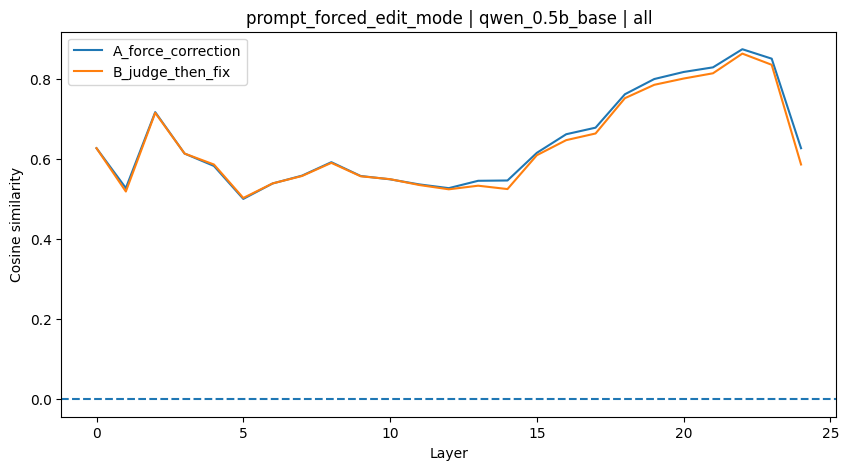

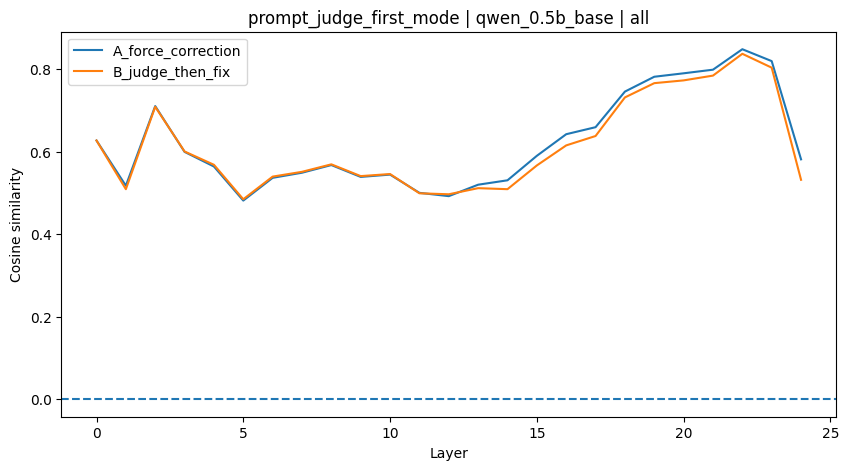

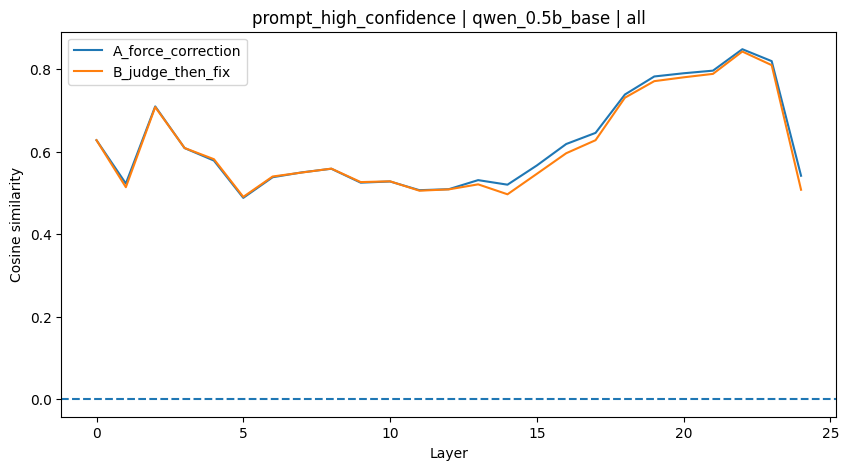

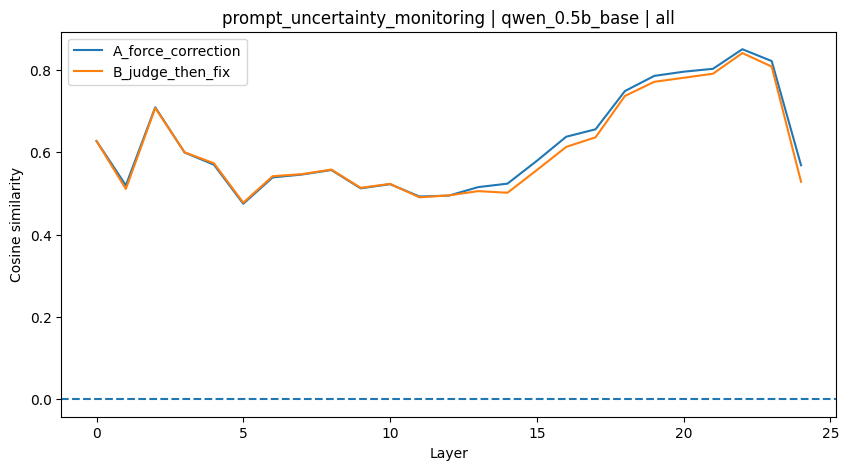

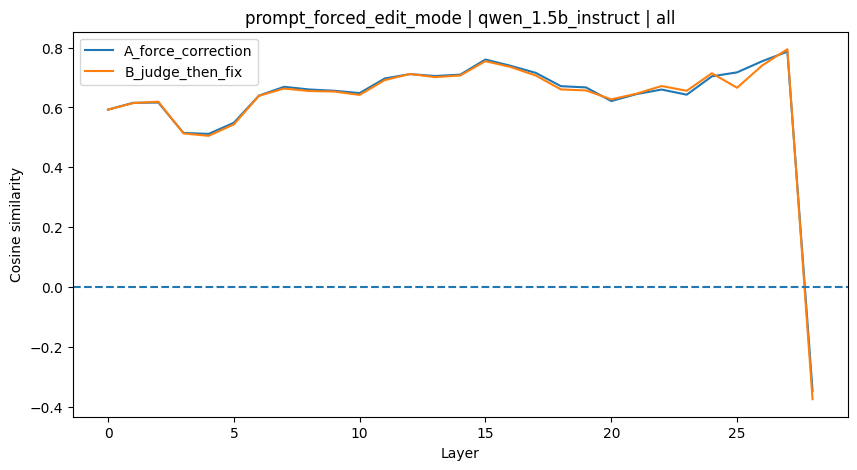

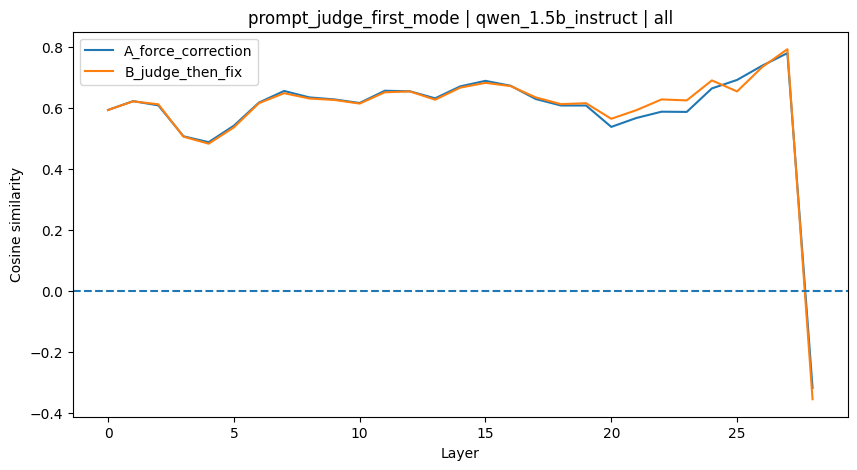

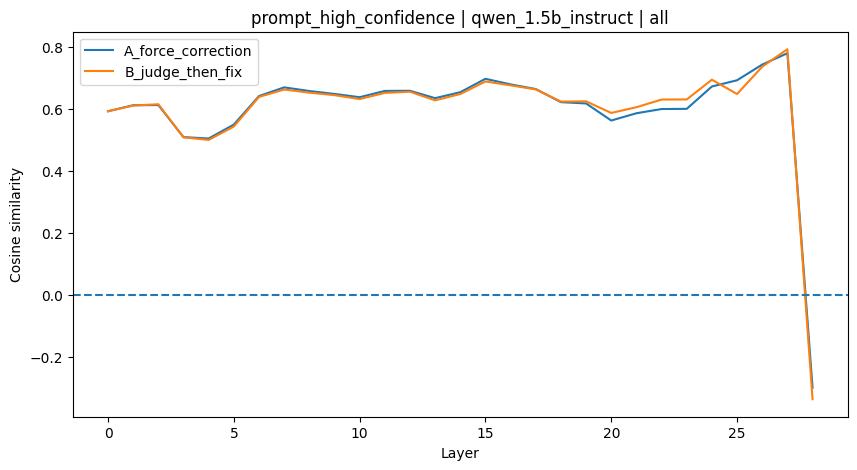

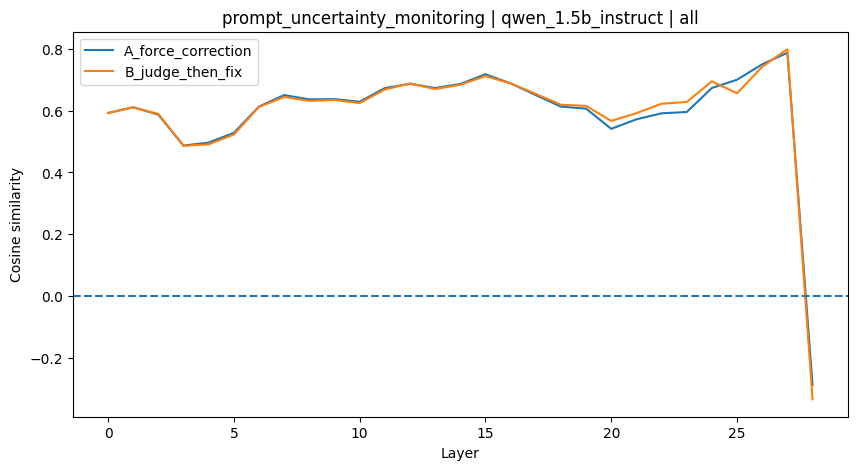

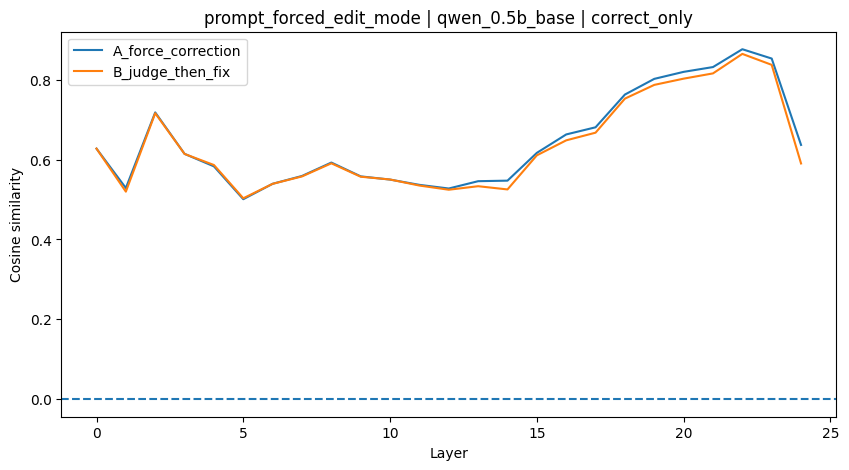

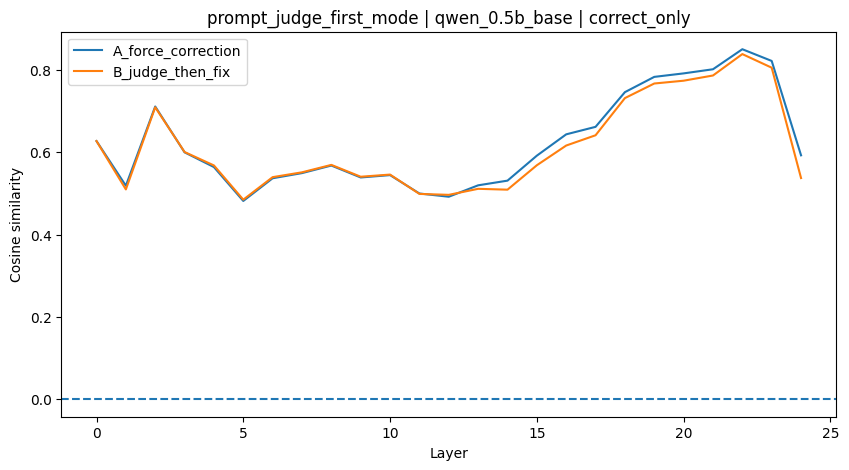

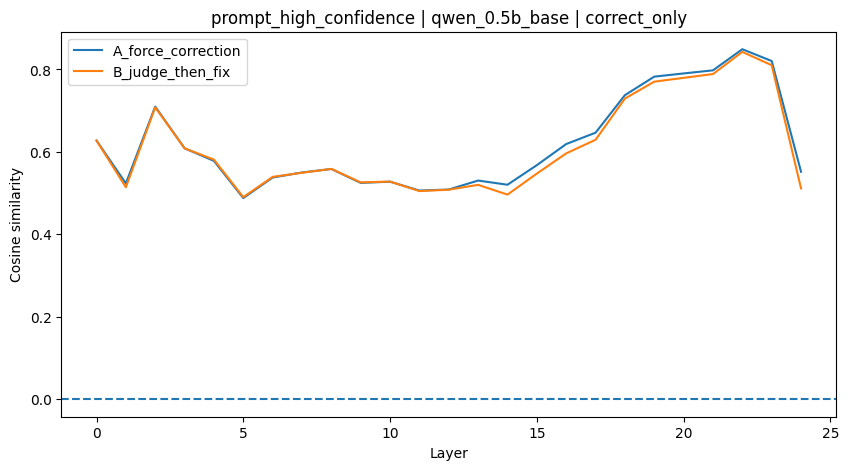

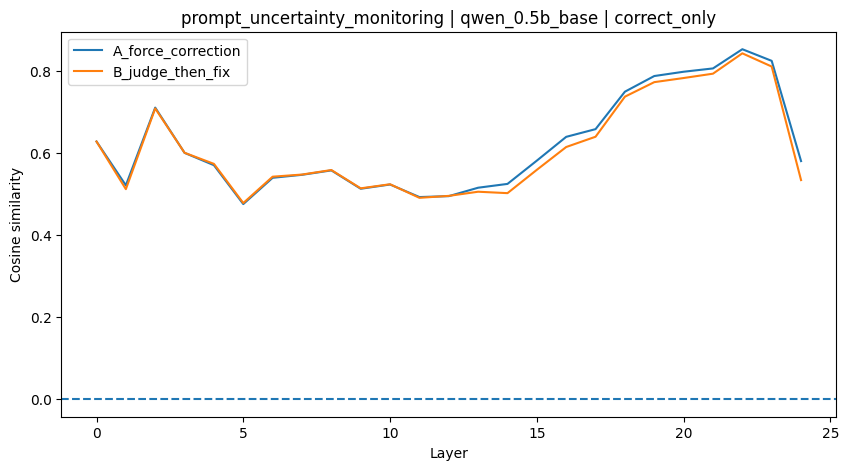

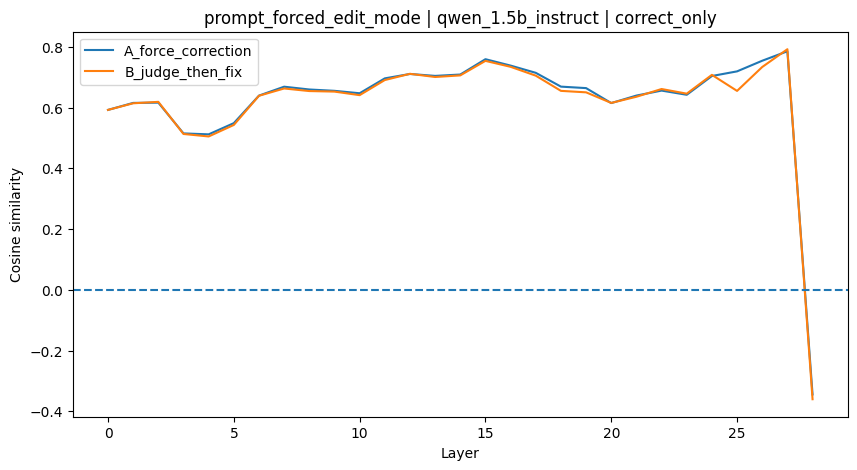

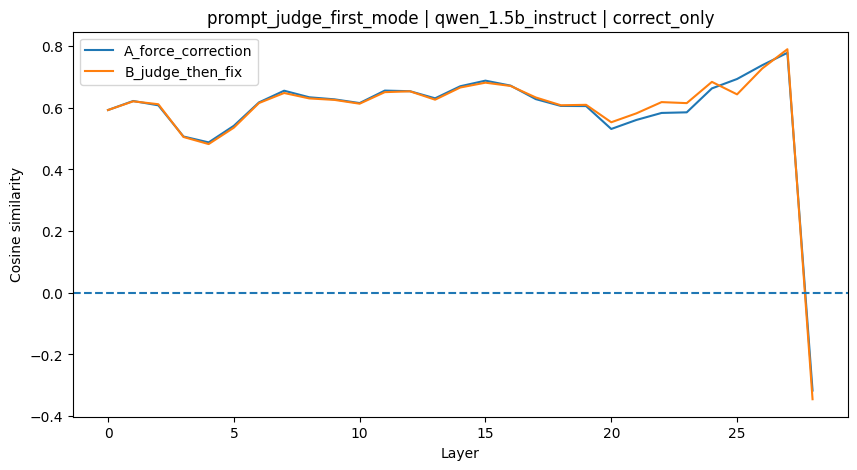

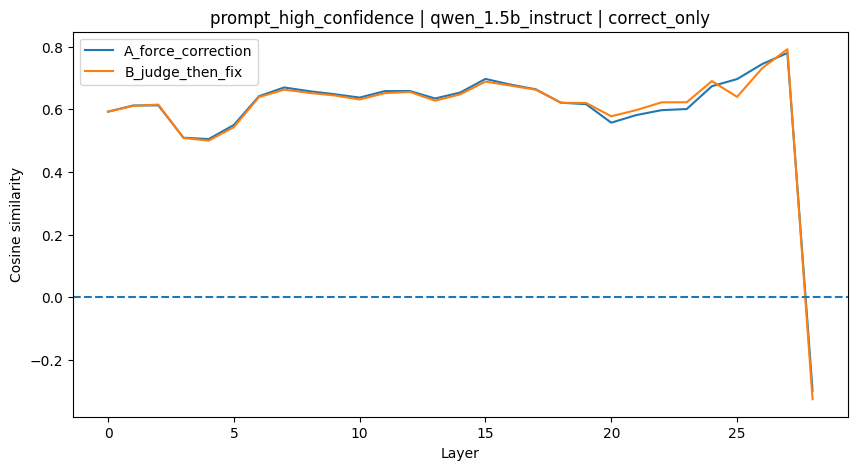

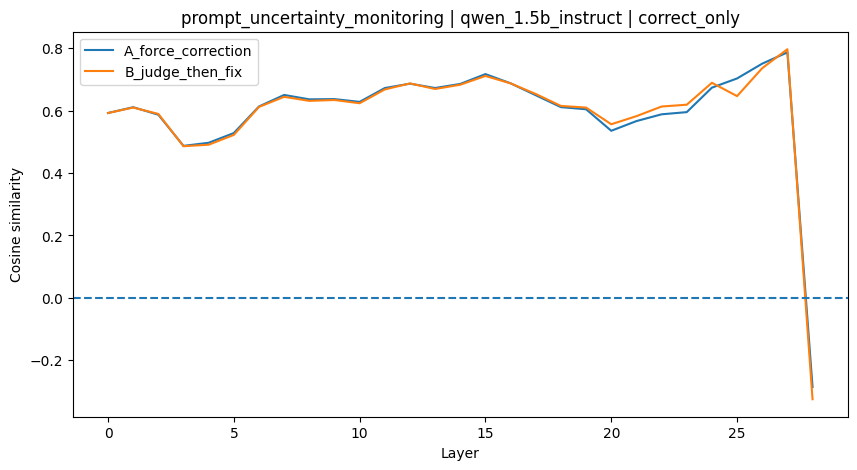

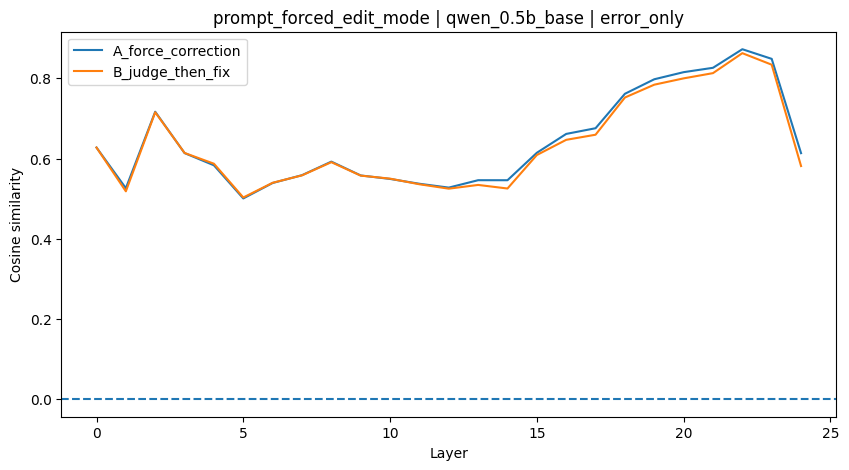

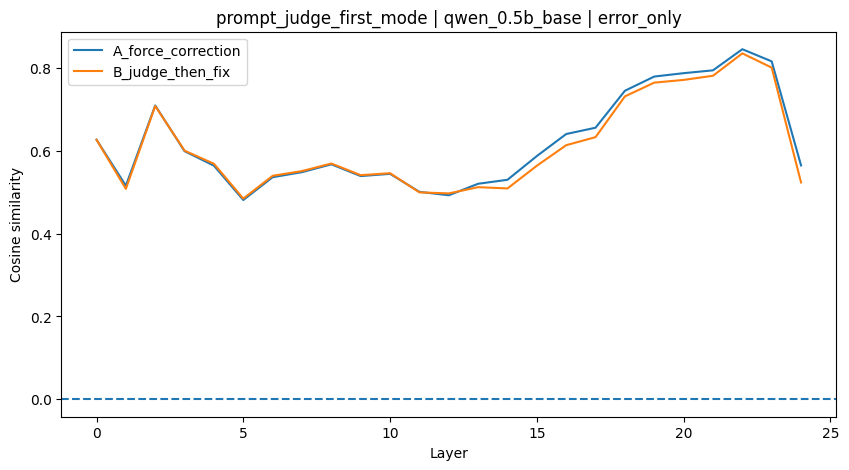

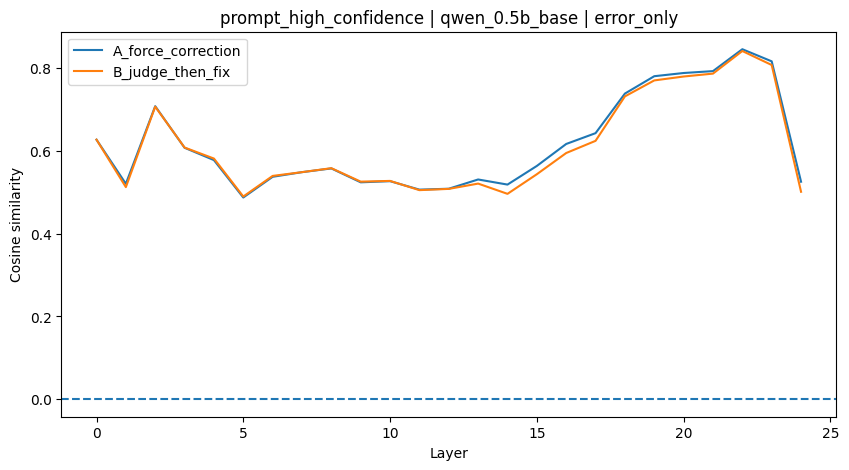

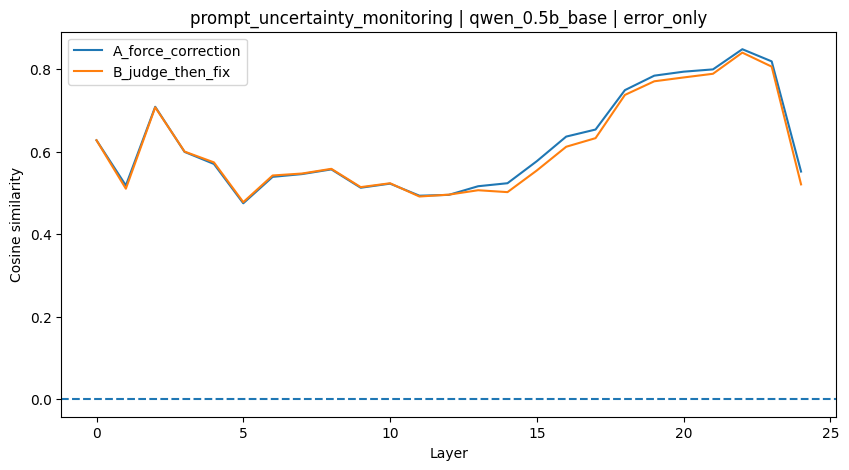

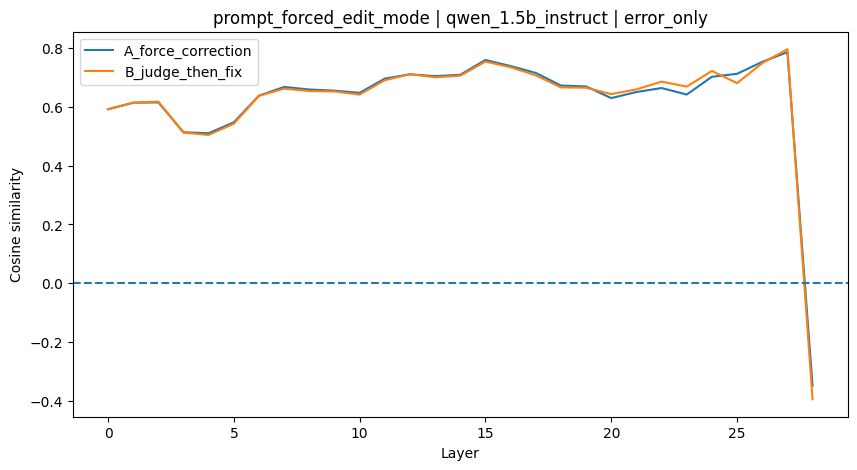

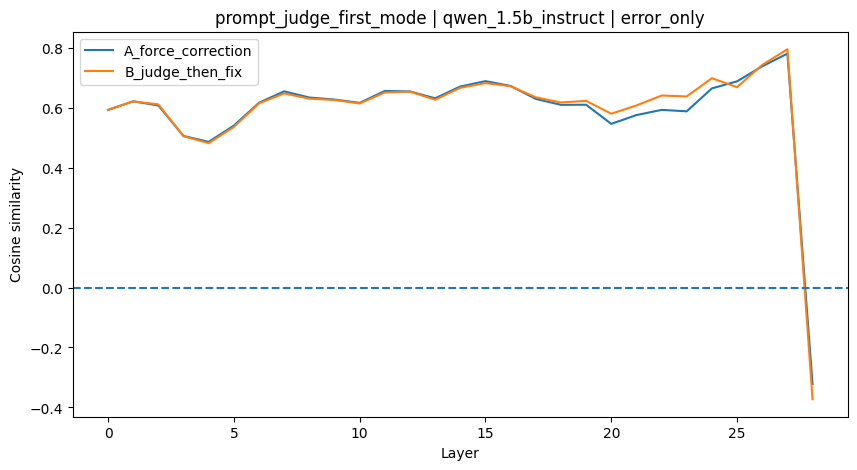

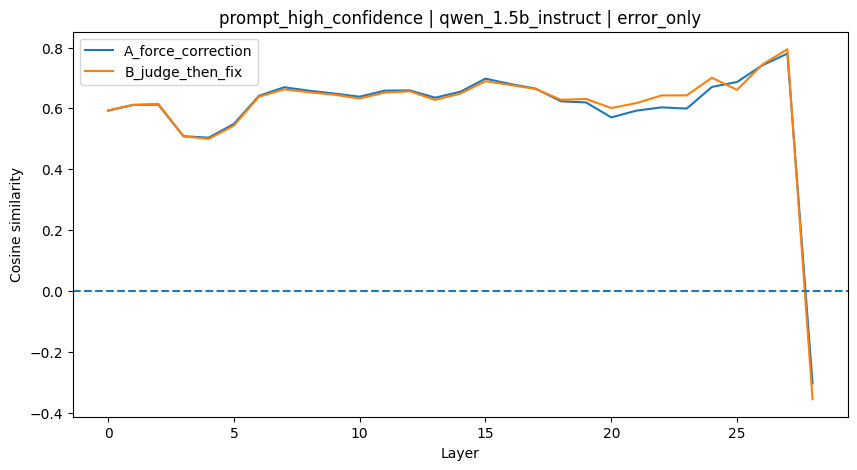

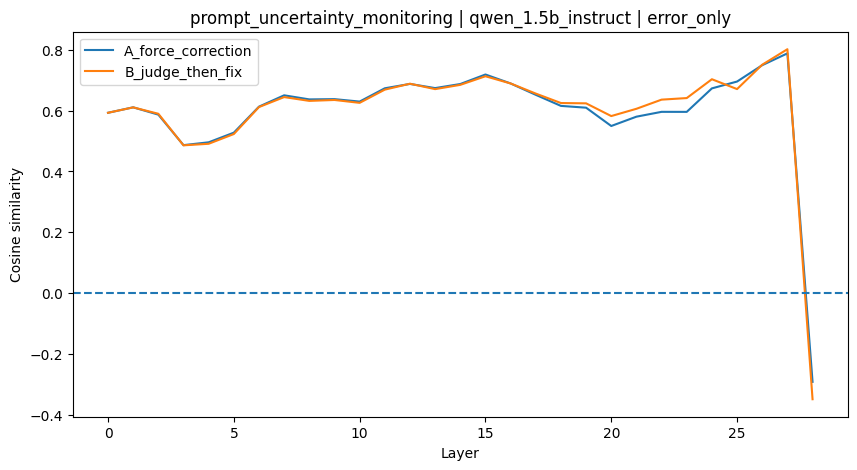

In [16]:

# Cell 16: 層ごとの可視化（prompt 側）
for subset_name, subset_value in [("all", None), ("correct_only", False), ("error_only", True)]:
    for model_label in df_layers["model_label"].unique():
        sub = df_layers[df_layers["model_label"] == model_label].copy()
        if subset_value is not None:
            sub = sub[sub["has_error"] == subset_value]

        if len(sub) == 0:
            continue

        plot_df = (
            sub.groupby(["condition", "layer"])[
                ["prompt_forced_edit_mode", "prompt_judge_first_mode", "prompt_high_confidence", "prompt_uncertainty_monitoring"]
            ]
            .mean()
            .reset_index()
        )

        for metric in ["prompt_forced_edit_mode", "prompt_judge_first_mode", "prompt_high_confidence", "prompt_uncertainty_monitoring"]:
            plt.figure(figsize=(10, 5))
            for cond in sorted(plot_df["condition"].unique()):
                s = plot_df[plot_df["condition"] == cond]
                plt.plot(s["layer"], s[metric], label=cond)
            plt.axhline(0, linestyle="--")
            plt.xlabel("Layer")
            plt.ylabel("Cosine similarity")
            plt.title(f"{metric} | {model_label} | {subset_name}")
            plt.legend()
            plt.show()


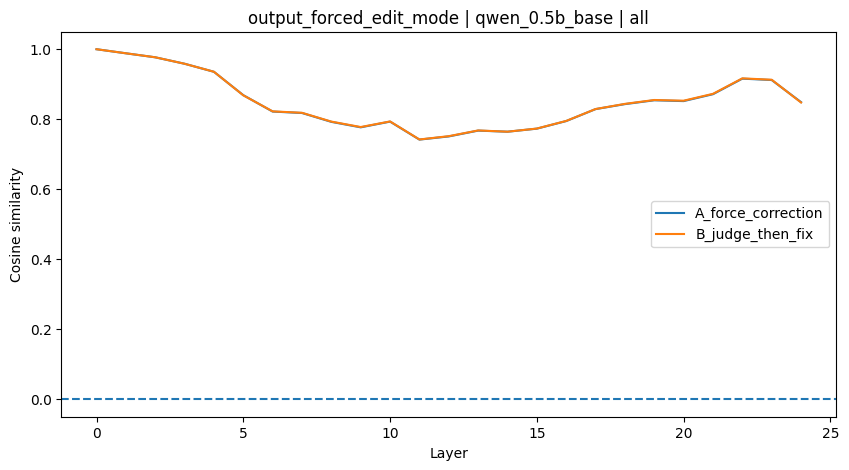

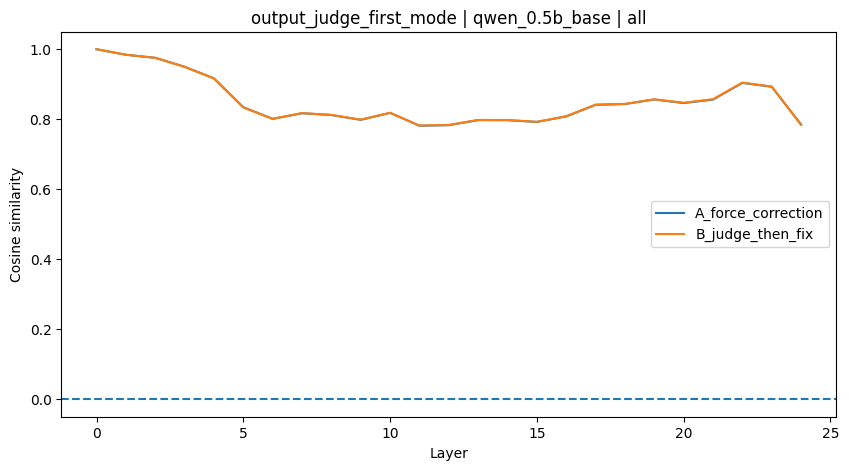

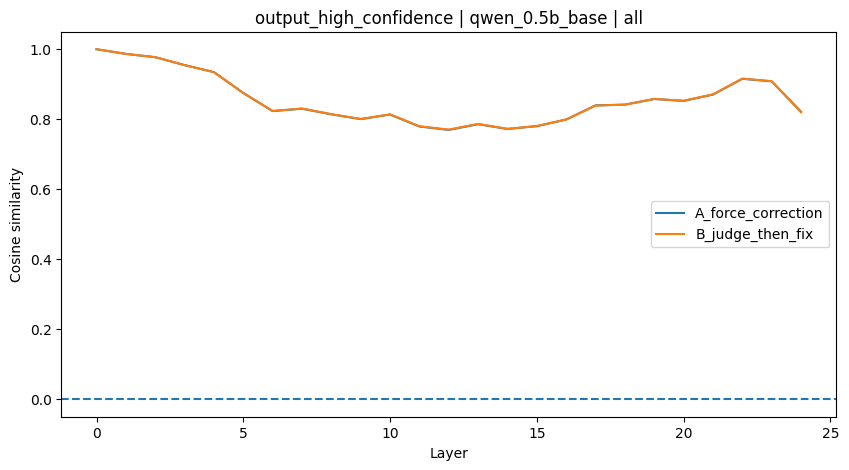

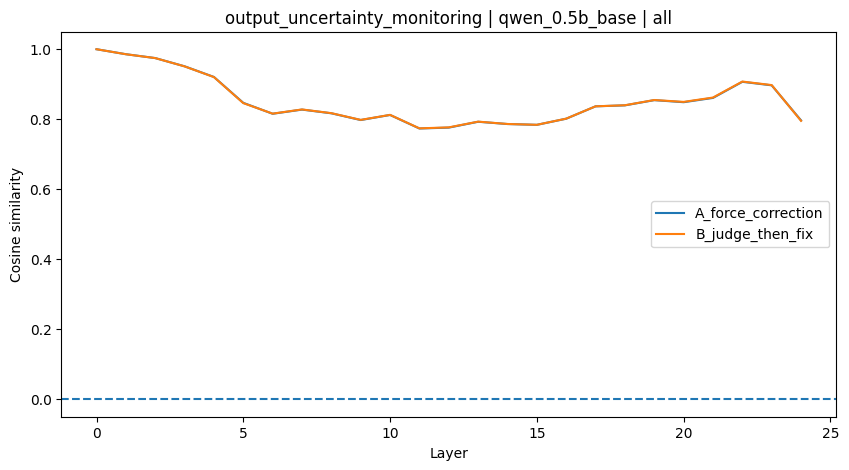

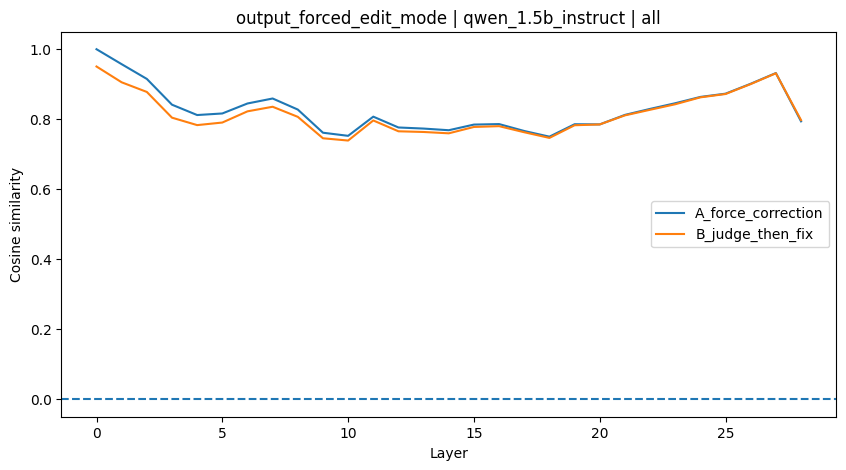

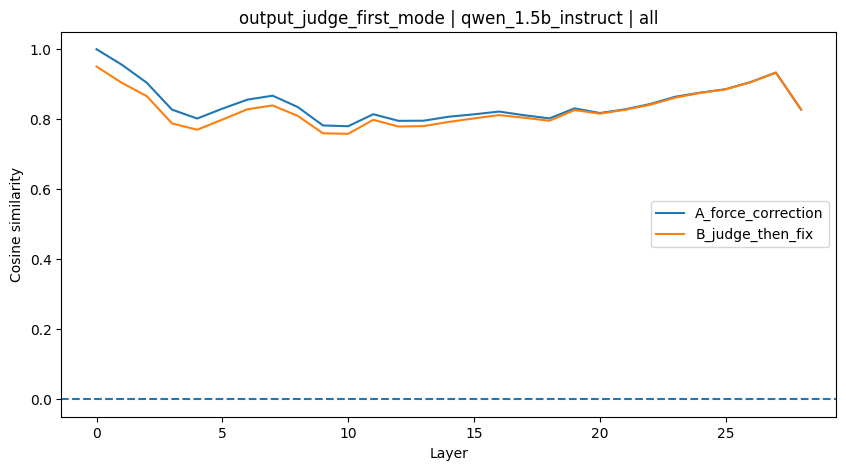

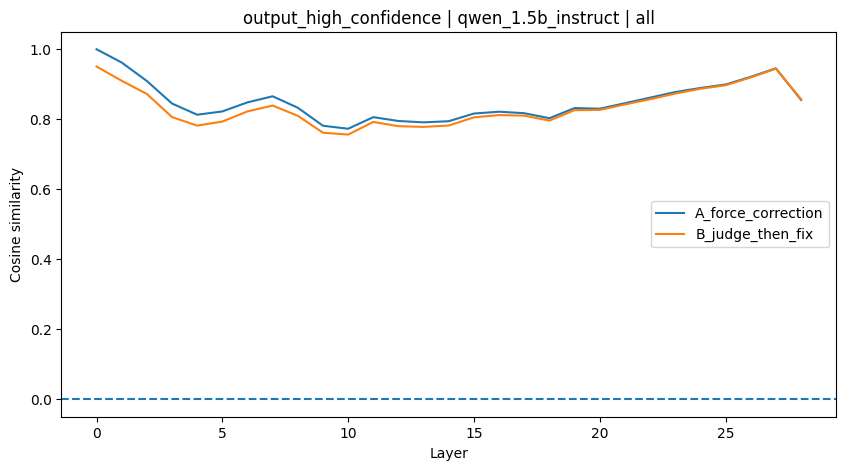

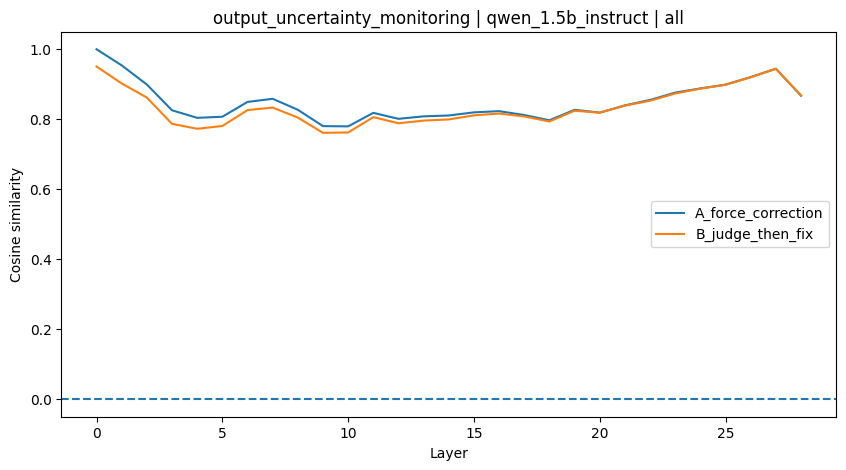

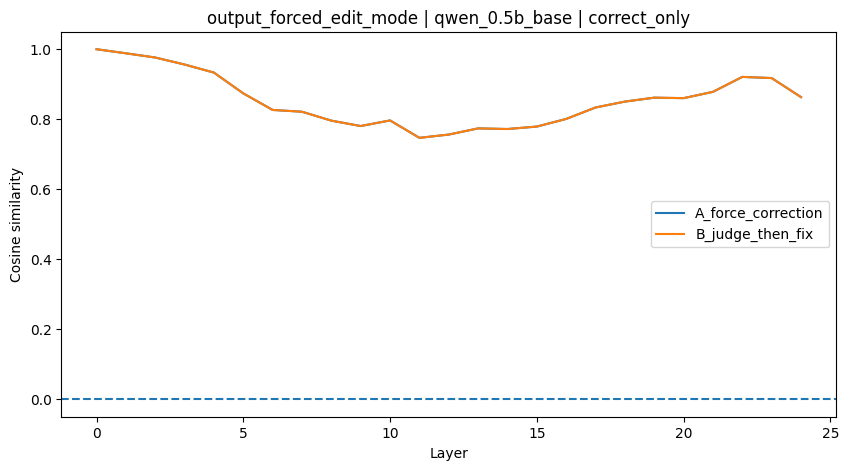

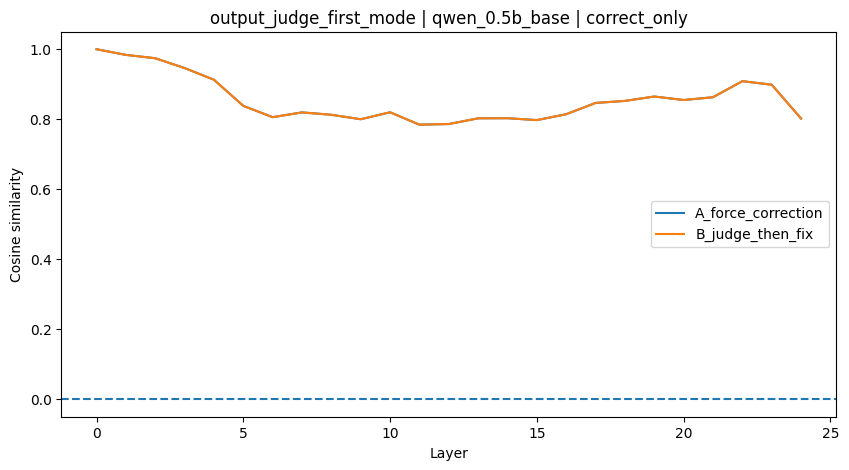

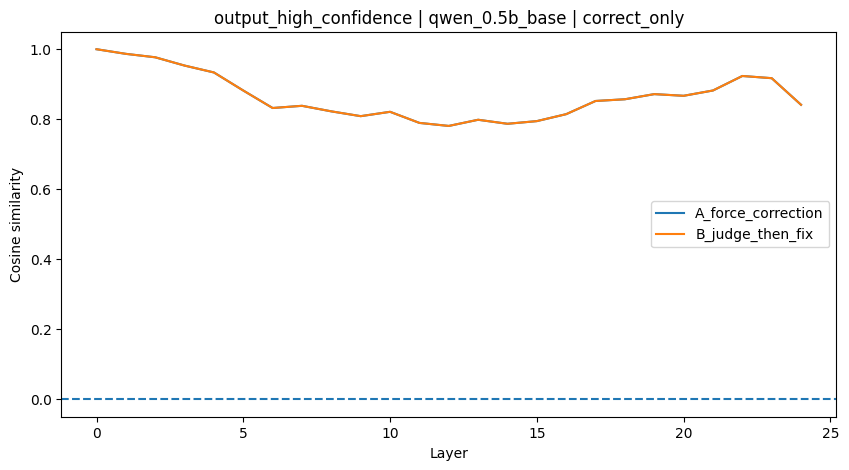

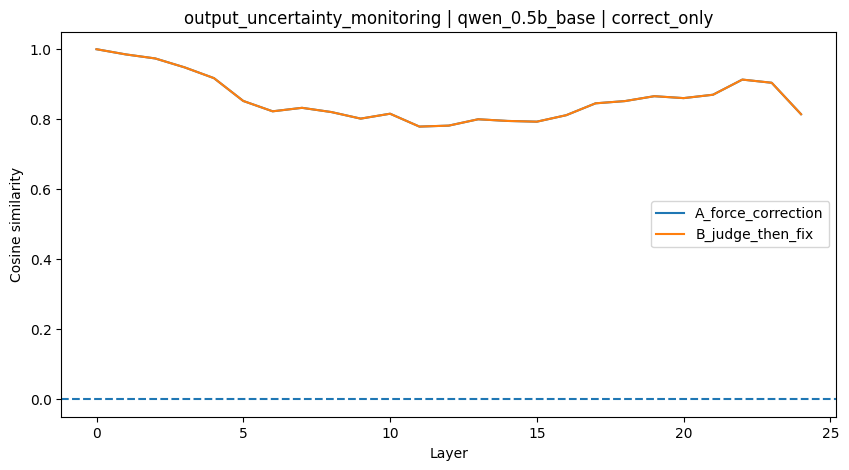

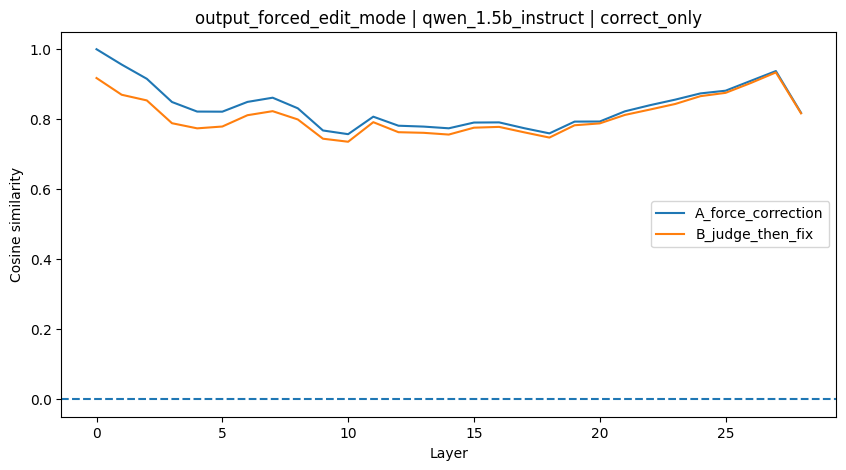

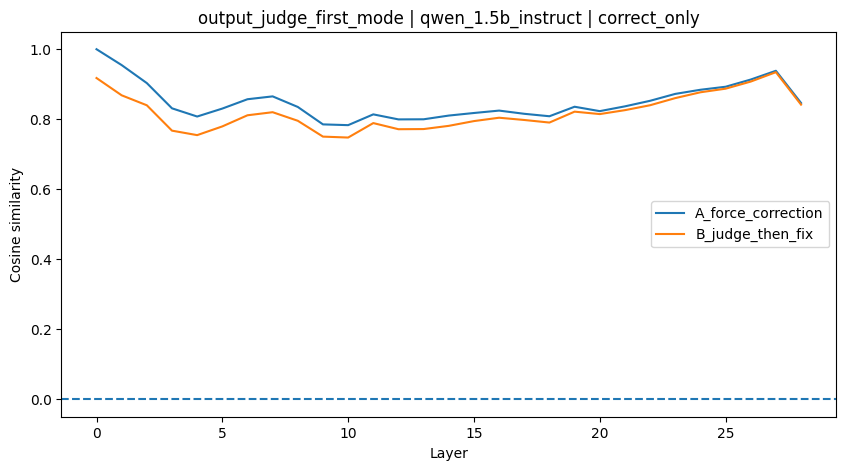

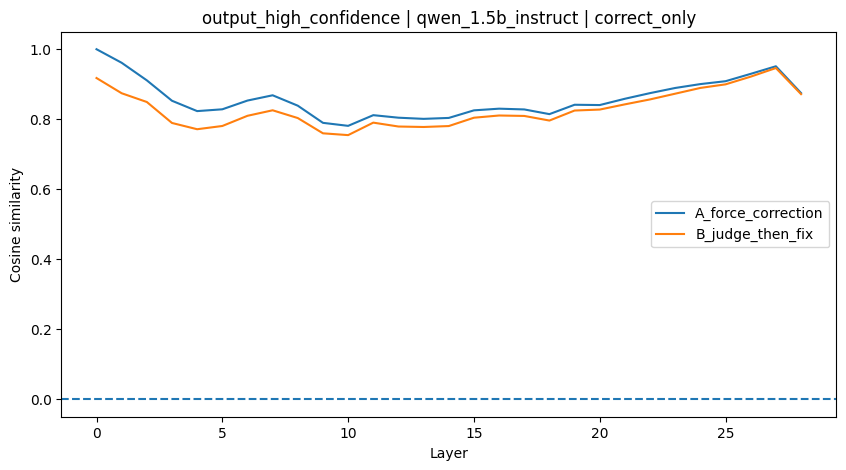

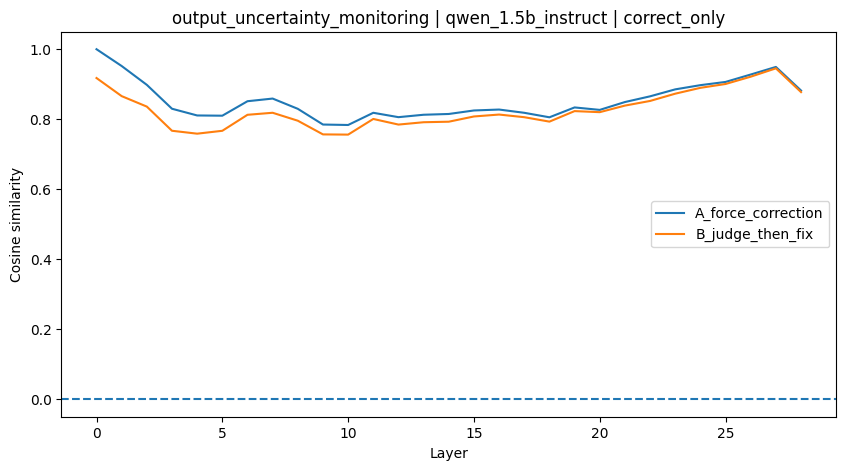

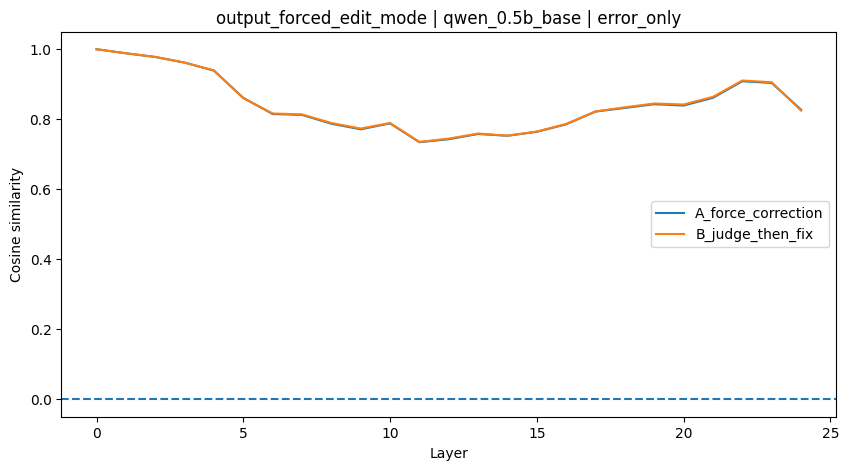

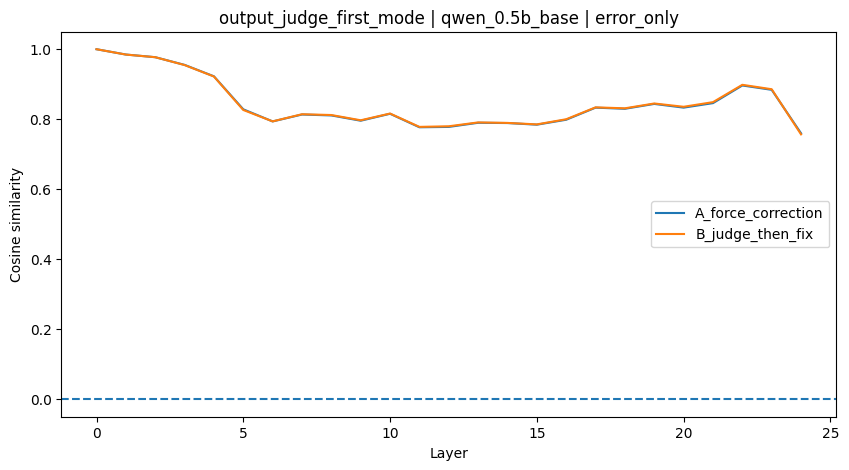

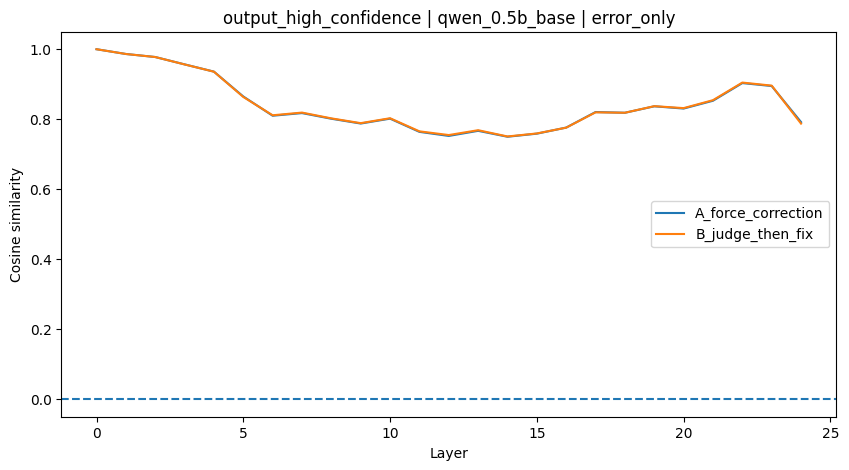

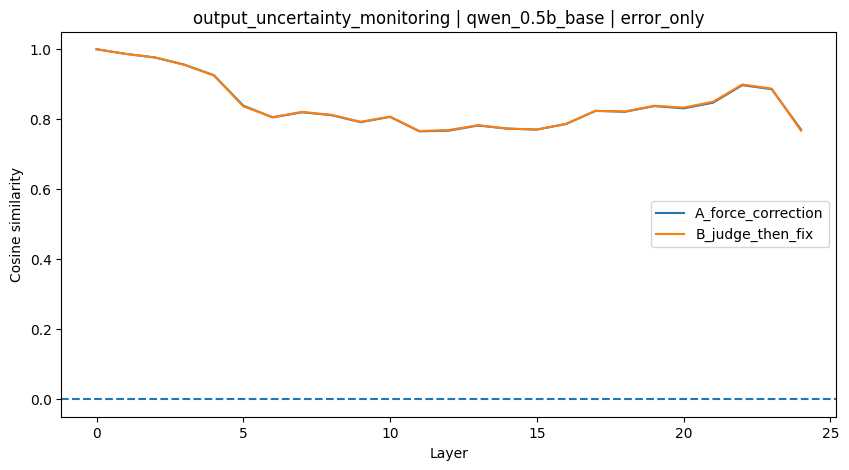

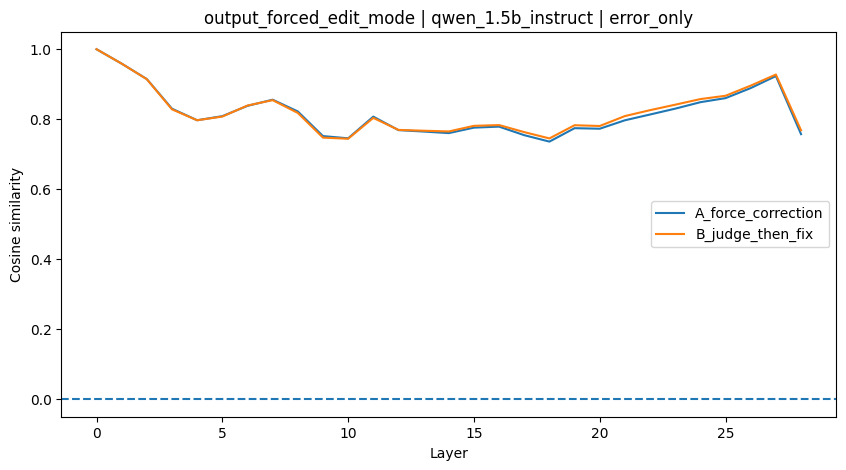

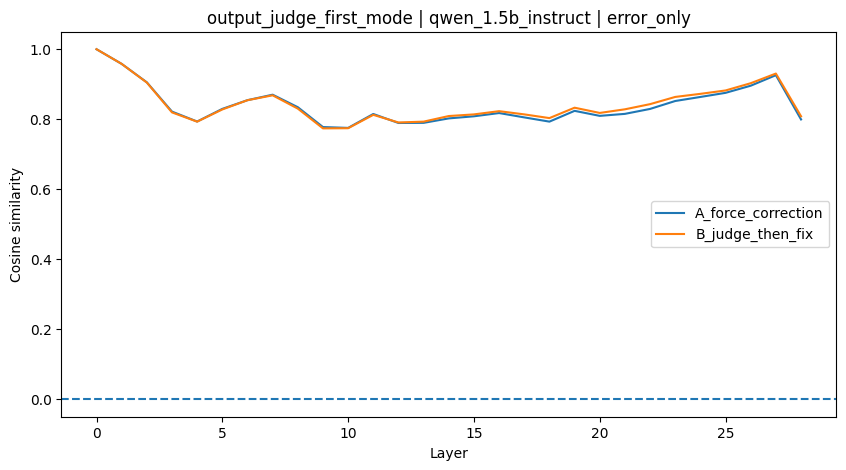

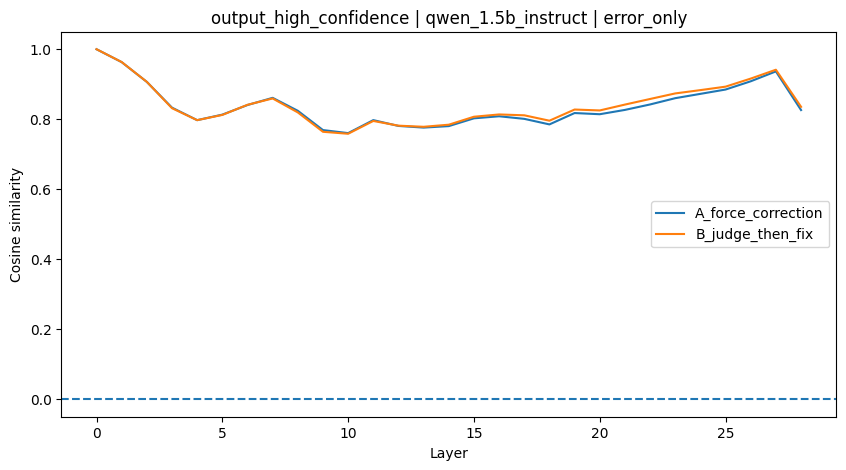

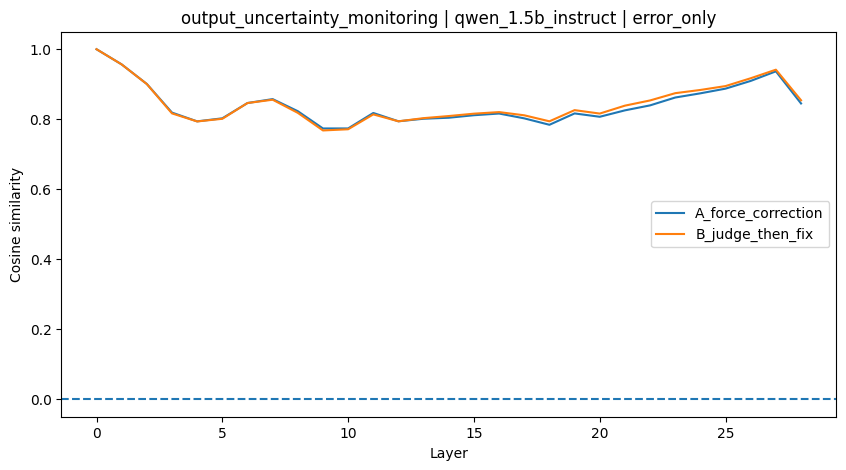

In [17]:

# Cell 17: 層ごとの可視化（output 側）
for subset_name, subset_value in [("all", None), ("correct_only", False), ("error_only", True)]:
    for model_label in df_layers["model_label"].unique():
        sub = df_layers[df_layers["model_label"] == model_label].copy()
        if subset_value is not None:
            sub = sub[sub["has_error"] == subset_value]

        if len(sub) == 0:
            continue

        plot_df = (
            sub.groupby(["condition", "layer"])[
                ["output_forced_edit_mode", "output_judge_first_mode", "output_high_confidence", "output_uncertainty_monitoring"]
            ]
            .mean()
            .reset_index()
        )

        for metric in ["output_forced_edit_mode", "output_judge_first_mode", "output_high_confidence", "output_uncertainty_monitoring"]:
            plt.figure(figsize=(10, 5))
            for cond in sorted(plot_df["condition"].unique()):
                s = plot_df[plot_df["condition"] == cond]
                plt.plot(s["layer"], s[metric], label=cond)
            plt.axhline(0, linestyle="--")
            plt.xlabel("Layer")
            plt.ylabel("Cosine similarity")
            plt.title(f"{metric} | {model_label} | {subset_name}")
            plt.legend()
            plt.show()



## 読み取り方

### まず見るべき出力指標
- `preserved_when_correct_rate`  
  正しい文をそのまま維持できた率
- `overcorrected_when_correct_rate`  
  正しい文を余計に書き換えた率
- `corrected_when_needed_rate`  
  誤文を正しく直せた率

### まず見るべき内部表現指標
- `prompt_last_forced_edit_mode`  
  指示を読んだ時点で「とにかく書き換える」方向に寄っているか
- `prompt_last_judge_first_mode`  
  「まず正誤判定してから処理する」方向に寄っているか
- `prompt_last_uncertainty_monitoring`  
  「変更前に確認が必要」という監視モードに寄っているか

### 良い結果のパターン
- **A_force_correction** で `overcorrected_when_correct_rate` が上がる
- **B_judge_then_fix** で `preserved_when_correct_rate` が上がる
- prompt で  
  - A: `forced_edit_mode` 上昇
  - B: `judge_first_mode`, `uncertainty_monitoring` 上昇
- 差が特に **correct_only** の層別プロットで見える

### もしまだ差が出ないなら
次はさらに出力形式を固定するとよいです。たとえば：

- A: `OUTPUT ONLY THE CORRECTED SENTENCE`
- B: `IF CORRECT, OUTPUT EXACTLY "KEEP"; IF INCORRECT, OUTPUT THE CORRECTED SENTENCE`

このように、条件分岐を**トークン列として露出**させると、内部状態差がさらに観測しやすくなります。
